In [1]:
import pandas as pd
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/abcnews-date-text.csv')
df

,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers
...,...,...
1103660,20171231,the ashes smiths warners near miss liven up bo...
1103661,20171231,timelapse: brisbanes new year fireworks
1103662,20171231,what 2017 meant to the kids of australia
1103663,20171231,what the papodopoulos meeting may mean for ausus


In [2]:
df=df.iloc[0:100000]
df.drop('publish_date',axis=1,inplace=True)
df

/tmp/ipykernel_12104/1099388907.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('publish_date',axis=1,inplace=True)


,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers
...,...
99995,brazil creating gm cow to make drugs
99996,bruce to stay at birmingham
99997,bureau plays down fears over coastal waters
99998,bus maintenance workers industrial action cond...


In [3]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
text=df.headline_text
text=text.str.replace('[^\w ]','',regex=True)
text

<>:5: SyntaxWarning: invalid escape sequence '\w'
<>:5: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipykernel_12104/1155462229.py:5: SyntaxWarning: invalid escape sequence '\w'
  text=text.str.replace('[^\w ]','',regex=True)
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,headline_text
0,aba decides against community broadcasting lic...
1,act fire witnesses must be aware of defamation
2,a g calls for infrastructure protection summit
3,air nz staff in aust strike for pay rise
4,air nz strike to affect australian travellers
...,...
99995,brazil creating gm cow to make drugs
99996,bruce to stay at birmingham
99997,bureau plays down fears over coastal waters
99998,bus maintenance workers industrial action cond...


In [4]:
sw=stopwords.words('english')
from nltk.stem import SnowballStemmer
nltk.download('punkt_tab')
sbs=SnowballStemmer('english')
text=text.apply(lambda line:[sbs.stem(word) for word in nltk.word_tokenize(line) if word.lower() not in sw and len(word)>1]).apply(lambda line:' '.join(line))
text



[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,headline_text
0,aba decid communiti broadcast licenc
1,act fire wit must awar defam
2,call infrastructur protect summit
3,air nz staff aust strike pay rise
4,air nz strike affect australian travel
...,...
99995,brazil creat gm cow make drug
99996,bruce stay birmingham
99997,bureau play fear coastal water
99998,bus mainten worker industri action condemn


In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
vector=TfidfVectorizer()
x=vector.fit_transform(text)
x

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 523314 stored elements and shape (100000, 18730)>

In [6]:
x.toarray()

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
  km=KMeans(n_clusters=i,random_state=11)
  km.fit(x)
  wcss.append(km.inertia_)
wcss

[99687.69545912776,
 99424.3044343197,
 99321.93590280403,
 99058.38806737491,
 98926.59362633122,
 98709.46968593911,
 98619.27800817705,
 98540.55734558009,
 98303.31453229292,
 98112.07289630675]

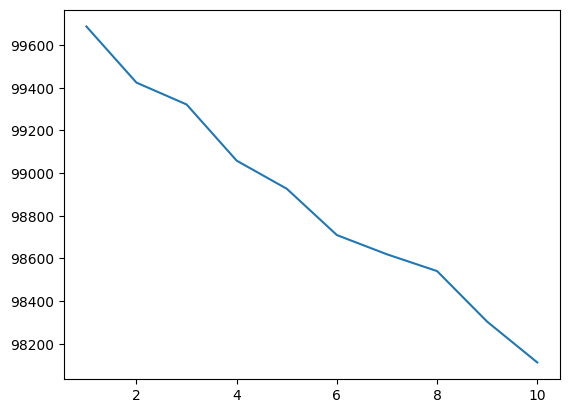

In [8]:
import matplotlib.pyplot as plt
plt.plot(range(1,11),wcss)
plt.show()

In [9]:
kmobj=KMeans(n_clusters=6,random_state=11)
kmobj.fit(x)
y=kmobj.predict(x)

In [10]:
from sklearn.metrics import silhouette_score
print(silhouette_score(x,y))

0.003401342526286428


In [11]:
df['clusters']=y
df

/tmp/ipykernel_12104/71677933.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clusters']=y


,headline_text,clusters
0,aba decides against community broadcasting lic...,0
1,act fire witnesses must be aware of defamation,0
2,a g calls for infrastructure protection summit,0
3,air nz staff in aust strike for pay rise,0
4,air nz strike to affect australian travellers,0
...,...,...
99995,brazil creating gm cow to make drugs,0
99996,bruce to stay at birmingham,0
99997,bureau plays down fears over coastal waters,0
99998,bus maintenance workers industrial action cond...,0


In [12]:
cv=df.loc[df['clusters']==2]
cv

,headline_text,clusters
70,heavy metal deposits survey nearing end,2
189,vowles to retire at end of season,2
242,cristal end eight match libertadores losing st...,2
466,aust share market ends week in negative territory,2
514,death spells end to record marriage,2
...,...,...
99501,sydney man found,2
99502,sydney observatory threatened by budget cut,2
99581,frawley to step down at end of season,2
99694,saiki ends 14 year lpga title drought,2


In [14]:
d={}
for i in range(6):
  d[f'cluster {i}']=df.loc[df['clusters']==i]
d


{'cluster 0':                                            headline_text  clusters
 0      aba decides against community broadcasting lic...         0
 1         act fire witnesses must be aware of defamation         0
 2         a g calls for infrastructure protection summit         0
 3               air nz staff in aust strike for pay rise         0
 4          air nz strike to affect australian travellers         0
 ...                                                  ...       ...
 99995               brazil creating gm cow to make drugs         0
 99996                        bruce to stay at birmingham         0
 99997        bureau plays down fears over coastal waters         0
 99998  bus maintenance workers industrial action cond...         0
 99999                      call for drip feed baby bonus         0
 
 [88100 rows x 2 columns],
 'cluster 1':                                            headline_text  clusters
 185           us british aircraft attack sth iraq target    